**Recomandation System**

**Data Preprocessing**

In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('anime.csv')
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
#check shape
print('row:',df.shape[0])
print('columns:',df.shape[1])

row: 12294
columns: 7


In [4]:
#display column names
print('column names:')
print(df.columns.tolist)

column names:
<bound method IndexOpsMixin.tolist of Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')>


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [6]:
#statistical summary of numerical columns
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [7]:
#missing values
print(df.isnull().sum())

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


In [8]:
# Handle missing categorical values
df["genre"] = df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")

# Handle missing rating values using median
df["rating"] = df["rating"].fillna(df["rating"].median())

In [9]:
print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [10]:
# Check duplicate rows
print("Number of duplicate rows:",
df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df=df.drop_duplicates()

In [12]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [13]:
print('final dataset shape:',df.shape)

final dataset shape: (12294, 7)


**2.Feature Extraction**

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [15]:
features=['genre','type','episodes','rating','members']
print('selected features ')
print(features)

selected features 
['genre', 'type', 'episodes', 'rating', 'members']


In [16]:
#convert genre into numerical
# Split genres into individual genres
genre_list = df["genre"].apply(
    lambda x: [g.strip() for g in str(x).split(",")]
)
# Convert genres into binary numerical features
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(genre_list)
# Create DataFrame
genre_df = pd.DataFrame(
    genre_encoded,
    columns=mlb.classes_,
    index=df.index
)
print("Genre encoded shape:", genre_df.shape)
genre_df.head()

Genre encoded shape: (12294, 44)


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#convert anime type into numerical
type_encoded=pd.get_dummies(df['type'])
type_encoded.head()

,Movie,Music,ONA,OVA,Special,TV,Unknown
0,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False
2,False,False,False,False,False,True,False
3,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False


In [18]:
#convert numerical features
# Convert episodes to numeric
df["episodes_num"] = pd.to_numeric(
    df["episodes"],
    errors="coerce"
)
# Fill missing episode values with median
df["episodes_num"] = df["episodes_num"].fillna(
    df["episodes_num"].median()
)
# Convert rating and members to numeric
df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)
df["members"] = pd.to_numeric(
    df["members"],
    errors="coerce"
)
# Fill missing values
df["rating"] = df["rating"].fillna(df["rating"].median())
df["members"] = df["members"].fillna(df["members"].median())

In [19]:
#normalize numerical features
# Select numerical features
numeric_features = df[
    ["episodes_num", "rating", "members"]
]
# Standardize numerical features
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(
    numeric_features
)
# Convert to DataFrame
numeric_df = pd.DataFrame(
    numeric_scaled,
    columns=[
        "episodes_scaled",
        "rating_scaled",
        "members_scaled"
    ],
    index=df.index
)
numeric_df.head()

,episodes_scaled,rating_scaled,members_scaled
0,-0.239941,2.845534,3.330241
1,1.122451,2.737388,14.148406
2,0.841323,2.727556,1.754713
3,0.257440,2.648904,11.957666
4,0.841323,2.639073,2.429742


In [20]:
#combine all extracted fatures
# Combine all features
feature_matrix = pd.concat(
    [
        genre_df,
        type_encoded,
        numeric_df
    ],
    axis=1
)
print("Final feature matrix shape:")
print(feature_matrix.shape)
feature_matrix.head()

Final feature matrix shape:
(12294, 54)


,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Movie,Music,ONA,OVA,Special,TV,Unknown,episodes_scaled,rating_scaled,members_scaled
0,0,0,0,0,0,0,1,0,0,0,...,True,False,False,False,False,False,False,-0.239941,2.845534,3.330241
1,1,1,0,0,0,0,1,0,1,0,...,False,False,False,False,False,True,False,1.122451,2.737388,14.148406
2,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.841323,2.727556,1.754713
3,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.257440,2.648904,11.957666
4,1,0,0,1,0,0,0,0,0,0,...,False,False,False,False,False,True,False,0.841323,2.639073,2.429742


In [21]:
# Convert feature matrix to NumPy array
X = feature_matrix.values

print("Final numerical feature matrix:")
print(X.shape)

Final numerical feature matrix:
(12294, 54)


The features selected for the recommendation system are genre, anime
type, number of episodes, rating, and number of members. Genre and
anime type were converted into numerical representations using
encoding techniques. The numerical features were standardized using
StandardScaler so that features with larger values, such as members,
do not dominate the similarity calculation. The resulting feature
matrix can now be used to calculate cosine similarity between anime.

**3.Recomndation System**

In [22]:
from sklearn.metrics.pairwise import cosine_similarity
# Calculate cosine similarity
cosine_sim = cosine_similarity(X)
print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (12294, 12294)


In [23]:
#create anime index
# Create mapping from anime name to dataframe index
anime_indices = pd.Series(
    df.index,
    index=df["name"]
).drop_duplicates()

print(anime_indices.head())

name
Kimi no Na wa.                      0
Fullmetal Alchemist: Brotherhood    1
Gintama°                            2
Steins;Gate                         3
Gintama&#039;                       4
dtype: int64


In [24]:
#create rec function
def recommend_anime(title, n=10, threshold=0.3):
    
    # Check whether anime exists
    if title not in anime_indices:
        print("Anime not found.")
        return pd.DataFrame()
    
    # Get index of target anime
    idx = anime_indices[title]
    
    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )
    
    # Sort anime by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )
    
    # Remove the target anime itself
    similarity_scores = [
        (i, score)
        for i, score in similarity_scores
        if i != idx
    ]
    
    # Apply similarity threshold
    recommendations = [
        (i, score)
        for i, score in similarity_scores
        if score >= threshold
    ]
    
    # Select top N recommendations
    recommendations = recommendations[:n]
    
    # Create result dataframe
    result = df.loc[
        [i for i, score in recommendations],
        ["name", "genre", "type", "episodes", "rating", "members"]
    ].copy()
    
    # Add similarity score
    result["similarity_score"] = [
        round(score, 4)
        for i, score in recommendations
    ]
    
    return result

In [27]:
#test the system
# Test recommendation
recommendations = recommend_anime(
    "Kimi no Na wa.",
    n=10,
    threshold=0.3
)
recommendations

,name,genre,type,episodes,rating,members,similarity_score
60,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,1,8.61,197439,0.9463
25,Suzumiya Haruhi no Shoushitsu,"Comedy, Mystery, Romance, School, Sci-Fi, Supe...",Movie,1,8.81,240297,0.9122
71,Hotaru no Haka,"Drama, Historical",Movie,1,8.58,174878,0.9006
504,"Clannad: After Story - Mou Hitotsu no Sekai, K...","Drama, Romance, School",Special,1,8.02,138364,0.8921
186,Kotonoha no Niwa,"Drama, Psychological, Romance, Slice of Life",Movie,1,8.35,189741,0.8902
219,Yahari Ore no Seishun Love Comedy wa Machigatt...,"Comedy, Drama, Romance, School",TV,13,8.31,222994,0.8864
35,Howl no Ugoku Shiro,"Adventure, Drama, Fantasy, Romance",Movie,1,8.74,333186,0.8832
132,Toki wo Kakeru Shoujo,"Adventure, Drama, Romance, Sci-Fi",Movie,1,8.44,289206,0.8814
370,"Clannad: Mou Hitotsu no Sekai, Tomoyo-hen","Drama, Romance, School, Slice of Life",Special,1,8.14,160423,0.8733
11,Koe no Katachi,"Drama, School, Shounen",Movie,1,9.05,102733,0.8727


In [28]:
#experiment with diff threshold values
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for threshold in thresholds:
    result = recommend_anime(
        "Kimi no Na wa.",
        n=20,
        threshold=threshold
    )
    print(
        "Threshold:",
        threshold,
        "| Number of Recommendations:",
        len(result)
    )

Threshold: 0.1 | Number of Recommendations: 20
Threshold: 0.2 | Number of Recommendations: 20
Threshold: 0.3 | Number of Recommendations: 20
Threshold: 0.4 | Number of Recommendations: 20
Threshold: 0.5 | Number of Recommendations: 20
Threshold: 0.6 | Number of Recommendations: 20
Threshold: 0.7 | Number of Recommendations: 20
Threshold: 0.8 | Number of Recommendations: 20


In [29]:
#display rec for diff threshold
for threshold in [0.3, 0.5, 0.7, 0.9]:
    print("\n" + "=" * 60)
    print("Similarity Threshold:", threshold)
    result = recommend_anime(
        "Kimi no Na wa.",
        n=10,
        threshold=threshold
    )
    if len(result) > 0:
        print(
            result[
                ["name", "rating", "similarity_score"]
            ].to_string(index=False)
        )
    else:
        print("No recommendations found.")


Similarity Threshold: 0.3
                                                    name  rating  similarity_score
                                      Hotarubi no Mori e    8.61            0.9463
                           Suzumiya Haruhi no Shoushitsu    8.81            0.9122
                                          Hotaru no Haka    8.58            0.9006
   Clannad: After Story - Mou Hitotsu no Sekai, Kyou-hen    8.02            0.8921
                                        Kotonoha no Niwa    8.35            0.8902
Yahari Ore no Seishun Love Comedy wa Machigatteiru. Zoku    8.31            0.8864
                                     Howl no Ugoku Shiro    8.74            0.8832
                                   Toki wo Kakeru Shoujo    8.44            0.8814
               Clannad: Mou Hitotsu no Sekai, Tomoyo-hen    8.14            0.8733
                                          Koe no Katachi    9.05            0.8727

Similarity Threshold: 0.5
                                 

In [30]:
threshold_results = []
for threshold in np.arange(0.1, 1.0, 0.1):
    result = recommend_anime(
        "Kimi no Na wa.",
        n=20,
        threshold=threshold
    )
    threshold_results.append({
        "Threshold": round(threshold, 1),
        "Number_of_Recommendations": len(result)
    })
threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Number_of_Recommendations
0,0.1,20
1,0.2,20
2,0.3,20
3,0.4,20
4,0.5,20
5,0.6,20
6,0.7,20
7,0.8,20
8,0.9,3


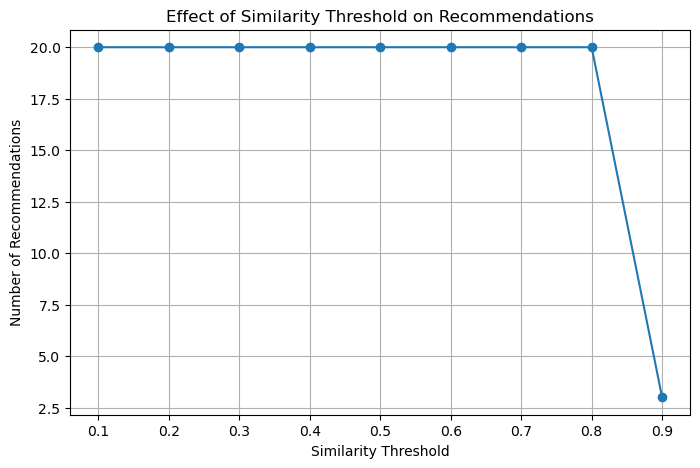

In [31]:
#visualize threshold performance
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Number_of_Recommendations"],
    marker="o"
)
plt.xlabel("Similarity Threshold")
plt.ylabel("Number of Recommendations")
plt.title("Effect of Similarity Threshold on Recommendations")
plt.grid(True)
plt.show()

Performance Analysis:

1. At a lower similarity threshold, the system provides more
   recommendations.

2. Increasing the threshold reduces the number of recommendations.

3. Lower thresholds provide a wider range of anime but may include
   less relevant recommendations.

4. Higher thresholds provide fewer recommendations, but the
   recommended anime are more similar to the target anime.

5. A moderate threshold such as 0.3 or 0.5 can provide a balance
   between recommendation quantity and similarity.

6. The recommendation system is useful for finding anime with
   similar genres, types, ratings, episodes and popularity.

Areas for Improvement:

1. Include user-specific rating history to provide personalized
   recommendations.

2. Use collaborative filtering along with content-based filtering.

3. Include additional features such as studio, producer, season,
   source and synopsis.

4. Use TF-IDF on anime descriptions to improve content similarity.

5. The number of members may represent popularity rather than
   actual similarity, so its weight can be reduced.

6. The similarity threshold can be optimized using user feedback.

7. A larger user-anime rating dataset can be used to evaluate
   recommendation accuracy more effectively.

Conclusion:

A content-based anime recommendation system was implemented using
cosine similarity. Genre, type, episodes, rating and members were used
as features. Categorical features were converted into numerical
representations and numerical features were normalized before
calculating similarity.

The system can take an anime title as input and return a list of
similar anime. Different similarity thresholds were tested to control
the recommendation list size. The system can be further improved by
incorporating user preferences and collaborative filtering to provide
more personalized recommendations.

**Interview Questions**

1. Difference Between User-Based and Item-Based Collaborative Filtering

 User-Based Collaborative Filtering:

User-based collaborative filtering finds users who have similar preferences
and recommends items that those similar users liked.

Example:
If User A and User B like similar anime, and User B likes another anime
that User A has not watched, that anime can be recommended to User A.

 Item-Based Collaborative Filtering:

Item-based collaborative filtering finds items that are similar based on
user ratings or interactions.

Example:
If a user likes Anime A, and users who liked Anime A also liked Anime B,
then Anime B can be recommended.

 Difference

| User-Based | Item-Based |
|------------|------------|
| Finds similar users | Finds similar items |
| Uses user preferences | Uses item ratings/interactions |
| Recommends items liked by similar users | Recommends similar items |

 2. What is Collaborative Filtering and How Does It Work?

Collaborative filtering is a recommendation technique that recommends
items based on the preferences and behavior of users.

It can use information such as:

- User ratings
- Likes and dislikes
- Watch history
- Purchases
- Views

 Working Process

User-Item Interaction Data
        ↓
Create User-Item Matrix
        ↓
Find Similar Users or Items
        ↓
Predict User Preferences
        ↓
Generate Recommendations

 Types of Collaborative Filtering

1. User-Based Collaborative Filtering
2. Item-Based Collaborative Filtering

Example

If many users who liked Anime A also liked Anime B, then Anime B can be
recommended to a user who likes Anime A.